<a href="https://colab.research.google.com/github/rajnish80130/Real-state-Capstone-Project/blob/main/missing_value_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/gurgaon_properties_outlier_treated.csv')
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,la vida by tata housing,sector 113,3.00,14286.0,2100.0,Super Built up area 2691(250 sq.m.)Built Up ar...,3,3,3+,...,2460.0,2100.0,0,1,0,0,0,0,167,700.0
1,flat,umang monsoon breeze,sector 78,0.88,4746.0,1854.0,Super Built up area 1854(172.24 sq.m.)Built Up...,3,4,3,...,1668.0,1501.0,0,1,0,1,0,0,111,618.0
2,flat,ireo the grand arch,sector 58,4.85,16934.0,2864.0,Carpet area: 2864 (266.07 sq.m.),4,5,3,...,NaN,2864.0,1,1,0,1,1,2,49,716.0
3,flat,m3m woodshire,sector 107,1.49,6311.0,2361.0,Super Built up area 2361(219.34 sq.m.),3,4,3+,...,NaN,NaN,0,1,1,0,0,2,174,787.0
4,flat,ambience creacions,sector 22,6.16,20533.0,3000.0,Carpet area: 3000 (278.71 sq.m.),4,5,3+,...,NaN,3000.0,0,1,0,1,0,2,49,750.0


In [3]:
df.shape

(3554, 24)

In [4]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


## Built-up Area

<Axes: xlabel='super_built_up_area', ylabel='built_up_area'>

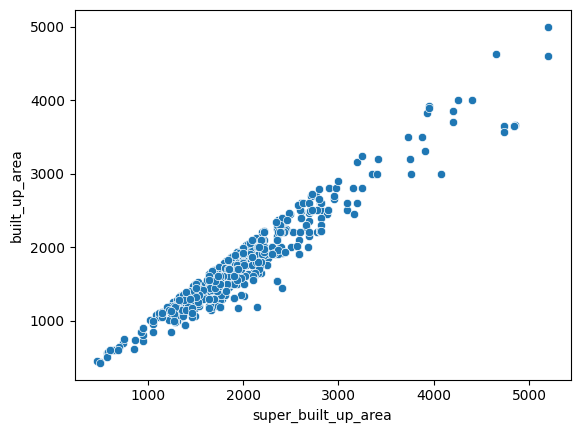

In [6]:
sns.scatterplot(x=df['super_built_up_area'],y=df['built_up_area'])

<Axes: xlabel='carpet_area', ylabel='built_up_area'>

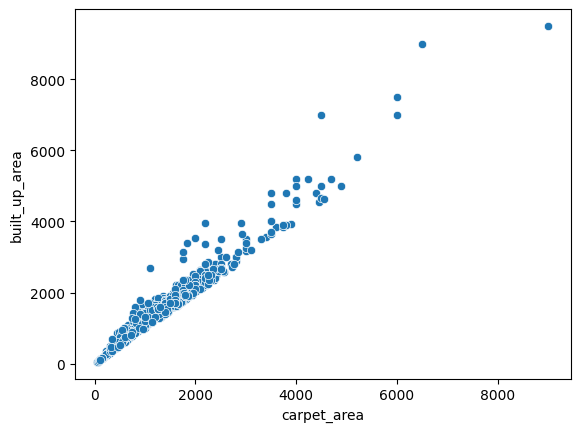

In [7]:
sns.scatterplot(x=df['carpet_area'],y=df['built_up_area'])

In [12]:
(df['super_built_up_area'].isnull() & df['built_up_area'].isnull() & df['carpet_area'].isnull())

,0
0,False
1,False
2,False
3,False
4,False
...,...
3549,False
3550,False
3551,False
3552,False


In [13]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [14]:
all_present_df.shape

(531, 24)

In [15]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [16]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [17]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [18]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [20]:
pd.set_option('display.max_columns',None)

In [21]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
25,flat,ats triumph,sector 104,1.75,7642.0,2290.0,Super Built up area 2290(212.75 sq.m.)Carpet a...,3,4,3+,12.0,North-West,Relatively New,2290.0,NaN,1800.0,1,1,0,1,1,2,21,763.333333
29,flat,ashiana anmol,sohna road,0.99,8216.0,1205.0,Super Built up area 1205(111.95 sq.m.)Carpet a...,2,2,2,6.0,East,Under Construction,1205.0,NaN,900.0,0,0,0,0,0,0,49,602.500000
32,flat,ambience creacions,sector 22,4.10,28101.0,1459.0,Super Built up area 2781(258.36 sq.m.)Carpet a...,3,3,3+,2.0,North-East,New Property,2781.0,NaN,1459.0,0,0,0,0,0,1,119,486.333333
40,flat,avl 36 gurgaon,sector 36a,0.75,7500.0,1000.0,Super Built up area 1000(92.9 sq.m.)Carpet are...,2,2,2,5.0,North-East,Relatively New,1000.0,NaN,727.0,0,0,0,0,0,0,26,500.000000
45,flat,indiabulls centrum park,sector 103,1.34,7486.0,1790.0,Super Built up area 1790(166.3 sq.m.)Carpet ar...,3,3,3+,13.0,South-East,Relatively New,1790.0,NaN,1350.0,1,0,0,0,0,0,93,596.666667


In [22]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

<ipython-input-22-a2fefc960aa3>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
<ipython-input-22-a2fefc960aa3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_

In [23]:
df.update(sbc_df)

In [24]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [25]:
# sb present carpet is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [26]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
3,flat,m3m woodshire,sector 107,1.49,6311.0,2361.0,Super Built up area 2361(219.34 sq.m.),3,4,3+,5.0,East,Relatively New,2361.0,NaN,NaN,0,1,1,0,0,2,174,787.000000
6,flat,tulip violet,sector 69,1.55,9823.0,1578.0,Super Built up area 1578(146.6 sq.m.),3,3,2,9.0,North-East,Relatively New,1578.0,NaN,NaN,0,0,0,1,0,2,165,526.000000
8,flat,kiran residency,sector 56,1.55,7750.0,2000.0,Super Built up area 2000(185.81 sq.m.),3,3,3,5.0,North,Old Property,2000.0,NaN,NaN,0,1,0,0,0,2,52,666.666667
11,flat,tulip violet,sector 69,1.75,8883.0,1970.0,Super Built up area 1970(183.02 sq.m.),4,4,1,12.0,North-West,Relatively New,1970.0,NaN,NaN,0,0,0,0,0,0,86,492.500000
22,flat,tulip violet,sector 69,2.05,9951.0,2060.0,Super Built up area 2087(193.89 sq.m.),4,4,2,0.0,North-West,Relatively New,2087.0,NaN,NaN,0,0,0,0,0,0,157,515.000000


In [27]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

<ipython-input-27-554030e2e595>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
<ipython-input-27-554030e2e595>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)


In [28]:
df.update(sb_df)

In [29]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [30]:
# sb null carpet is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [31]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
2,flat,ireo the grand arch,sector 58,4.85,16934.0,2864.0,Carpet area: 2864 (266.07 sq.m.),4,5,3,23.0,North-West,Relatively New,NaN,NaN,2864.0,1,1,0,1,1,2,49,716.000000
4,flat,ambience creacions,sector 22,6.16,20533.0,3000.0,Carpet area: 3000 (278.71 sq.m.),4,5,3+,10.0,South-East,New Property,NaN,NaN,3000.0,0,1,0,1,0,2,49,750.000000
7,flat,smart world gems,sector 89,1.20,8433.0,1423.0,Carpet area: 1423 (132.2 sq.m.),3,3,2,2.0,North-East,New Property,NaN,NaN,1423.0,0,0,0,0,0,0,44,474.333333
13,flat,maxworth city residences,sector 10a,0.80,6400.0,1250.0,Carpet area: 1250 (116.13 sq.m.),2,3,2,9.0,NaN,New Property,NaN,NaN,1250.0,0,0,0,0,0,0,46,625.000000
16,flat,signature global park,sohna road,0.68,8252.0,824.0,Carpet area: 824 (76.55 sq.m.),2,2,2,3.0,NaN,New Property,NaN,NaN,824.0,0,0,0,0,0,0,113,412.000000


In [32]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

<ipython-input-32-747bc7ee3c0e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
<ipython-input-32-747bc7ee3c0e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)


In [33]:
df.update(c_df)

In [34]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


<Axes: xlabel='built_up_area', ylabel='price'>

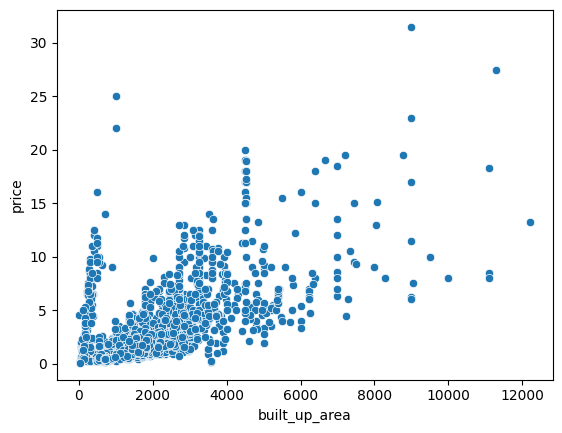

In [36]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [37]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [38]:
anamoly_df.sample(5)

,price,area,built_up_area
3291,2.90,2003.0,1813.0
1211,4.86,1875.0,1697.0
972,2.55,1630.0,1811.0
1771,5.50,2700.0,300.0
1047,2.99,1449.0,1449.0


In [39]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [40]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

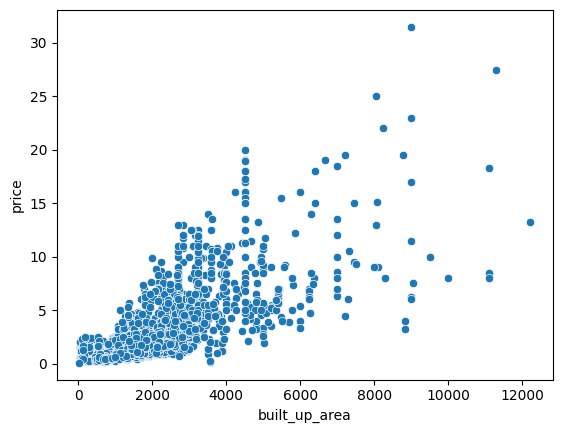

In [42]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [43]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [44]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,la vida by tata housing,sector 113,3.00,14286.0,3,3,3+,3.0,East,Relatively New,2460.0,0,1,0,0,0,0,167
1,flat,umang monsoon breeze,sector 78,0.88,4746.0,3,4,3,8.0,North-West,Moderately Old,1668.0,0,1,0,1,0,0,111
2,flat,ireo the grand arch,sector 58,4.85,16934.0,4,5,3,23.0,North-West,Relatively New,3182.0,1,1,0,1,1,2,49
3,flat,m3m woodshire,sector 107,1.49,6311.0,3,4,3+,5.0,East,Relatively New,2137.0,0,1,1,0,0,2,174
4,flat,ambience creacions,sector 22,6.16,20533.0,4,5,3+,10.0,South-East,New Property,3333.0,0,1,0,1,0,2,49


In [45]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,17
facing,1011


In [46]:
# floorNum
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
64,house,Independent,sector 7,6.50,15046.0,3,2,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,0,9
261,house,jacob pura,sector 12,0.35,9722.0,2,1,0,NaN,NaN,Old Property,360.0,0,0,0,0,0,0,0
343,flat,NaN,sector 78,0.60,3692.0,2,2,0,NaN,NaN,Under Construction,1625.0,0,0,0,0,0,0,0
378,house,Independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,0,0
493,house,Independent,sector 24,1.45,2984.0,3,3,1,NaN,NaN,Old Property,540.0,0,0,0,0,0,0,9
703,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,2,NaN,East,Moderately Old,3240.0,0,1,1,1,0,0,88
1039,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,0,0
1274,house,Independent,sector 4,4.12,8889.0,2,1,3+,NaN,NaN,Moderately Old,4635.0,0,0,0,0,0,0,0
1930,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,1,NaN,NaN,Relatively New,3240.0,0,0,0,0,0,0,21
2059,house,ansal sushant lok,sector 43,10.50,27911.0,4,4,2,NaN,North-East,Old Property,3762.0,0,1,0,0,0,0,59


In [47]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [48]:
df['floorNum'].fillna(2.0,inplace=True)

<ipython-input-48-4d4ca364c16c>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [49]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
facing,1011


In [52]:
# facing
1011/df.shape[0]

0.2844682048396173

<Axes: ylabel='count'>

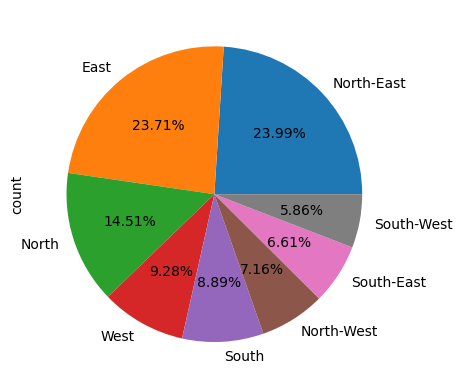

In [56]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [57]:
df.drop(columns=['facing'],inplace=True)

In [58]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3327,house,puri diplomatic greens,sector 111,9.00,11250.0,5,5,3+,3.0,Relatively New,8000.0,0,1,0,0,0,0,112
3073,flat,vatika gurgaon,sector 83,1.10,6162.0,3,3,3+,5.0,Relatively New,1600.0,0,0,0,0,0,2,96
1674,flat,paras dews,sector 106,1.05,7581.0,2,2,2,5.0,New Property,1539.0,0,0,0,0,0,0,97
2493,flat,corona optus,sector 37c,1.25,7090.0,3,3,3,4.0,Relatively New,1350.0,0,0,0,0,1,0,49
1726,flat,bptp terra,sector 37d,1.65,7531.0,4,3,3+,6.0,Relatively New,2091.0,0,0,0,0,0,2,149


In [59]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [60]:
df.dropna(subset=['society'],inplace=True)

In [61]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [62]:
df.shape

(3553, 18)

In [63]:
# agePossession
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1605
New Property,557
Moderately Old,545
Undefined,299
Old Property,292
Under Construction,255


In [64]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
14,house,Independent,sector 103,2.25,6367.0,3,5,3+,10.0,Undefined,3534.0,0,0,0,0,0,0,0
30,house,Independent,sector 9,0.22,7407.0,2,2,2,1.0,Undefined,37.0,0,0,0,0,0,0,0
44,flat,residency grand,sector 52,5.00,9615.0,5,5,3+,2.0,Undefined,5200.0,0,0,0,0,0,0,0
49,flat,elevate,sector 50,6.75,19882.0,4,4,0,10.0,Undefined,3395.0,0,0,0,0,0,0,0
55,flat,umang monsoon breeze,sector 78,0.70,5719.0,2,2,2,5.0,Undefined,1224.0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3506,flat,sare crescent parc,sector 92,1.00,4778.0,4,4,3,9.0,Undefined,2093.0,0,0,0,0,0,0,0
3512,house,Independent,sector 8,0.62,11273.0,3,1,0,2.0,Undefined,550.0,0,0,0,0,0,0,0
3517,house,Independent,sector 14,4.60,20444.0,1,1,0,1.0,Undefined,2250.0,0,0,0,0,0,0,0
3542,house,Independent,sector 10a,4.25,17955.0,4,3,2,1.0,Undefined,2367.0,0,0,0,0,0,0,0


In [65]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [66]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [67]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1717
New Property,598
Moderately Old,585
Old Property,326
Under Construction,269
Undefined,58


In [68]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [69]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [70]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1729
New Property,600
Moderately Old,592
Old Property,329
Under Construction,270
Undefined,33


In [71]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [72]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [73]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1731
Moderately Old,623
New Property,600
Old Property,329
Under Construction,270


In [74]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [75]:
df.shape

(3553, 18)

In [76]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)